# **CMSC320 Final Project**
## **Checkpoint 2**
### Group: Jerico Estrella, Tanush Parhi, Ronit Munshi, Jake Glendon, Sang Pham


In [1]:
# import libraries
import pandas as pd
from datetime import datetime
import string

### **Data preprocessing**

#### **Dataset #1**

(a) import

In [3]:
df1 = pd.read_csv("VideoGamesSales-2016.csv")
print(df1.shape)
print(df1.dtypes)
display(df1)

(16719, 16)
Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object
dtype: object


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


(b) parse

In [4]:
# makes all the string data in lowercase and makes sure any whitespace is removed
df1["Name"] = df1["Name"].str.lower().str.strip()
df1["Platform"] = df1["Platform"].str.lower().str.strip()
df1["Publisher"] = df1["Publisher"].str.lower().str.strip()
df1["Genre"] = df1["Genre"].str.lower().str.strip()
df1["Developer"] = df1["Developer"].str.lower().str.strip()
df1["Rating"] = df1["Rating"].str.lower().str.strip()

display(df1)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006.0,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,nintendo,e
1,super mario bros.,nes,1985.0,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,mario kart wii,wii,2008.0,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,nintendo,e
3,wii sports resort,wii,2009.0,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,nintendo,e
4,pokemon red/pokemon blue,gb,1996.0,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016.0,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,lma manager 2007,x360,2006.0,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,haitaka no psychedelica,psv,2016.0,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,spirits & spells,gba,2003.0,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# drops any sales that are NULL
df1 = df1.dropna(subset=["Global_Sales"])
# drops any duplucaite row entries
df1 = df1.drop_duplicates()
# only used rows where total sales greater than 0
df1 = df1[df1["Global_Sales"] > 0]

print(df1.shape)
display(df1)


(16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006.0,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,nintendo,e
1,super mario bros.,nes,1985.0,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,mario kart wii,wii,2008.0,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,nintendo,e
3,wii sports resort,wii,2009.0,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,nintendo,e
4,pokemon red/pokemon blue,gb,1996.0,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016.0,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,lma manager 2007,x360,2006.0,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,haitaka no psychedelica,psv,2016.0,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,spirits & spells,gba,2003.0,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# converts the year column to Int64 integers from floats, with any NaNs becoming nullable ints
df1["Year_of_Release"] = pd.to_numeric(df1['Year_of_Release'], errors='coerce').astype('Int64')
# makes sure that the user score stays in its numeric float64 types
df1["User_Score"] = pd.to_numeric(df1['User_Score'], errors='coerce')

print(df1.dtypes)
display(df1)


Name                object
Platform            object
Year_of_Release      Int64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Developer           object
Rating              object
dtype: object


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,nintendo,e
1,super mario bros.,nes,1985,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,mario kart wii,wii,2008,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,nintendo,e
3,wii sports resort,wii,2009,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,nintendo,e
4,pokemon red/pokemon blue,gb,1996,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,lma manager 2007,x360,2006,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,haitaka no psychedelica,psv,2016,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,spirits & spells,gba,2003,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# makes sure that the Critic_Score stays in its numeric float64 types
df1['Critic_Score'] = pd.to_numeric(df1['Critic_Score'], errors='coerce')

# Converts the critics_count and user-count columns to Int64 since they are whole numbers
# with any NaNs being converted to nullable integers
df1['Critic_Count'] = pd.to_numeric(df1['Critic_Count'], errors='coerce').astype('Int64')
df1['User_Count'] = pd.to_numeric(df1['User_Count'], errors='coerce').astype('Int64')

# makes sure the sales data is still in the form of float64 decimals
df1['JP_Sales'] = pd.to_numeric(df1['JP_Sales'], errors='coerce')
df1['NA_Sales'] = pd.to_numeric(df1['NA_Sales'], errors='coerce')
df1['EU_Sales'] = pd.to_numeric(df1['EU_Sales'], errors='coerce')
df1['Other_Sales'] = pd.to_numeric(df1['Other_Sales'], errors='coerce')
df1['Global_Sales'] = pd.to_numeric(df1['Global_Sales'], errors='coerce')

print(df1.dtypes)
display(df1)


Name                object
Platform            object
Year_of_Release      Int64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count         Int64
User_Score         float64
User_Count           Int64
Developer           object
Rating              object
dtype: object


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,wii sports,wii,2006,sports,nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51,8.0,322,nintendo,e
1,super mario bros.,nes,1985,platform,nintendo,29.08,3.58,6.81,0.77,40.24,NaN,<NA>,NaN,<NA>,NaN,NaN
2,mario kart wii,wii,2008,racing,nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73,8.3,709,nintendo,e
3,wii sports resort,wii,2009,sports,nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73,8.0,192,nintendo,e
4,pokemon red/pokemon blue,gb,1996,role-playing,nintendo,11.27,8.89,10.22,1.00,31.37,NaN,<NA>,NaN,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,ps3,2016,action,tecmo koei,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16715,lma manager 2007,x360,2006,sports,codemasters,0.00,0.01,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16716,haitaka no psychedelica,psv,2016,adventure,idea factory,0.00,0.00,0.01,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN
16717,spirits & spells,gba,2003,platform,wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,<NA>,NaN,<NA>,NaN,NaN


In [8]:
# cheecks if anu of the sales data has any nulls by suming up the total
# nulls in each column
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

df1[sales_cols].isnull().sum()


NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

(c) organize

In [9]:
# extracts all the common columns between this dataset and the second dataset below
df1 = df1[["Name", "Publisher", "Platform", "Genre", "Year_of_Release", "Global_Sales", "NA_Sales", "JP_Sales", "EU_Sales", "Other_Sales", "Critic_Score"]]

# makes all the column names lowercase and makes Name match the second dataset's name
renaming_scheme = {
    'Name': 'game_name',
    'Platform': 'platform',
    'Genre': 'genre',
    'Year_of_Release': 'release_year',
    'Publisher': 'publisher',
    'Developer': 'developer',
    'Critic_Score': 'critic_score',
    'Global_Sales': 'total_sales',
    'NA_Sales': 'na_sales',
    'JP_Sales': 'jp_sales',
    'EU_Sales': 'eu_sales',
    'Other_Sales': 'other_sales',
}

# renames all the columns according to the renaming scheme
df1 = df1.rename(columns=renaming_scheme)

print(df1.dtypes)
display(df1)


game_name        object
publisher        object
platform         object
genre            object
release_year      Int64
total_sales     float64
na_sales        float64
jp_sales        float64
eu_sales        float64
other_sales     float64
critic_score    float64
dtype: object


,game_name,publisher,platform,genre,release_year,total_sales,na_sales,jp_sales,eu_sales,other_sales,critic_score
0,wii sports,nintendo,wii,sports,2006,82.53,41.36,3.77,28.96,8.45,76.0
1,super mario bros.,nintendo,nes,platform,1985,40.24,29.08,6.81,3.58,0.77,NaN
2,mario kart wii,nintendo,wii,racing,2008,35.52,15.68,3.79,12.76,3.29,82.0
3,wii sports resort,nintendo,wii,sports,2009,32.77,15.61,3.28,10.93,2.95,80.0
4,pokemon red/pokemon blue,nintendo,gb,role-playing,1996,31.37,11.27,10.22,8.89,1.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16714,samurai warriors: sanada maru,tecmo koei,ps3,action,2016,0.01,0.00,0.01,0.00,0.00,NaN
16715,lma manager 2007,codemasters,x360,sports,2006,0.01,0.00,0.00,0.01,0.00,NaN
16716,haitaka no psychedelica,idea factory,psv,adventure,2016,0.01,0.00,0.01,0.00,0.00,NaN
16717,spirits & spells,wanadoo,gba,platform,2003,0.01,0.01,0.00,0.00,0.00,NaN


#### **Dataset #2**

(a) import

In [10]:
df2 = pd.read_csv("vgchartz-2024.csv")
df2.shape

(64016, 14)

(b) parse

In [11]:
# lowercasing
df2["title"] = df2["title"].str.lower().str.strip()
df2["console"] = df2["console"].str.lower().str.strip()
df2["publisher"] = df2["publisher"].str.lower().str.strip()
df2["genre"] = df2["genre"].str.lower().str.strip()

# Extract year in release_date column and make release year column
df2["release_date"] = pd.to_datetime(df2["release_date"])
df2["release_year"] = df2["release_date"].dt.year.astype("Int64")

# drop
df2 = df2.dropna(subset=["total_sales"]) # remove any missing/null values 
df2 = df2.drop_duplicates()

# filter
df2 = df2[df2["total_sales"] > 0] # only used rows where total sales greater than 0

# replace
df2["na_sales"] = df2["na_sales"].fillna(0)
df2["jp_sales"] = df2["jp_sales"].fillna(0)
df2["pal_sales"] = df2["pal_sales"].fillna(0)
df2["other_sales"] = df2["other_sales"].fillna(0)
df2["critic_score"] = df2["critic_score"] * 10 # Replace score to 100 scale


(c) organize

In [12]:
# Extract useful columns
df2 = df2[["title", "publisher", "console", "genre", "release_year", "total_sales", "na_sales", "jp_sales", "pal_sales", "other_sales", "critic_score"]]

# rename
df2 = df2.rename(columns={"title": "game_name"})
df2 = df2.rename(columns={"pal_sales": "eu_sales"})
df2 = df2.rename(columns={"console": "platform"})

print(df2.isna().sum())
df2

game_name           0
publisher           0
platform            0
genre               0
release_year       62
total_sales         0
na_sales            0
jp_sales            0
eu_sales            0
other_sales         0
critic_score    13592
dtype: int64


,game_name,publisher,platform,genre,release_year,total_sales,na_sales,jp_sales,eu_sales,other_sales,critic_score
0,grand theft auto v,rockstar games,ps3,action,2013,20.32,6.37,0.99,9.85,3.12,94.0
1,grand theft auto v,rockstar games,ps4,action,2014,19.39,6.06,0.60,9.71,3.02,97.0
2,grand theft auto: vice city,rockstar games,ps2,action,2002,16.15,8.41,0.47,5.49,1.78,96.0
3,grand theft auto v,rockstar games,x360,action,2013,15.86,9.06,0.06,5.33,1.42,NaN
4,call of duty: black ops 3,activision,ps4,shooter,2015,15.09,6.18,0.41,6.05,2.44,81.0
...,...,...,...,...,...,...,...,...,...,...,...
17565,root double: before crime * after days,yeti,x360,visual novel,2012,0.01,0.00,0.01,0.00,0.00,NaN
17566,gakuen hetalia,idea factory,ds,visual novel,2012,0.01,0.00,0.01,0.00,0.00,NaN
17567,chaos;child: love chu chu!!,5pb,psv,visual novel,2017,0.01,0.00,0.01,0.00,0.00,NaN
17568,doukoku soshite... doukoku soshite...,el dia,ps4,visual novel,2018,0.01,0.00,0.01,0.00,0.00,NaN


**Combining/Merging Datasets**

In [13]:
# Ensures game_name and platform columns in both datasets are similar format and style. Removes punctuation, lowercases, whitespace.
for col in ["game_name", "platform"]: 
    df1[col] = df1[col].str.lower().str.strip().str.replace(r'[^a-z0-9 ]', '', regex=True)
    df2[col] = df2[col].str.lower().str.strip().str.replace(r'[^a-z0-9 ]', '', regex=True)

# Combine
df = pd.merge(df1, df2, how="outer")

# Add
df["missing_count"] = df.isna().sum(axis=1) # keeps account on number of missing values per row

# Sort
df = df.sort_values(["game_name", "platform", "missing_count"], ascending=[True, True, True]) # Sorts by game_name then platform then missing count

# Drop/Remove
df = df.groupby(["game_name", "platform"], as_index=False).first() # groups same game_name on same platform, grabs first index which that is not a null value
df = df.drop(columns=["missing_count"])
df = df.dropna(subset=["publisher"]) # remove any missing/null values 

# Checking to see missing values after merging and cleaning data
print("After Merge & Cleaning Dups:")
print(df.shape)
print(df.isna().sum())

# Bin total sales into 5 categories
df["sales_lvl"] = pd.cut(df["total_sales"],
                            bins=[0, 0.05, 0.2, 0.45, 0.9, float("inf")],
                            labels=["poor", "low", "medium", "high", "hit"]
                         )
print(df["sales_lvl"].value_counts()) # displays distribution of values per categort

# Fill
df["critic_score"] = df["critic_score"].fillna(
    df.groupby(["genre", "sales_lvl"], observed=True)["critic_score"].transform("median")
)
df = df.dropna(subset=["critic_score"]) # remove any remaining missing/null values 

# Checking to see missing values after filling
print("After Filling:")
print(df.isna().sum())

df.sort_values(["critic_score"], ascending=False)


After Merge & Cleaning Dups:
(19280, 11)
game_name           0
platform            0
publisher           0
genre               0
release_year       71
total_sales         0
na_sales            0
jp_sales            0
eu_sales            0
other_sales         0
critic_score    10141
dtype: int64
sales_lvl
low       5907
poor      5360
medium    3455
hit       2415
high      2143
Name: count, dtype: int64
After Filling:
game_name        0
platform         0
publisher        0
genre            0
release_year    71
total_sales      0
na_sales         0
jp_sales         0
eu_sales         0
other_sales      0
critic_score     0
sales_lvl        0
dtype: int64


,game_name,platform,publisher,genre,release_year,total_sales,na_sales,jp_sales,eu_sales,other_sales,critic_score,sales_lvl
13000,red dead redemption undead nightmare,ps3,rockstar games,action,2010,1.18,0.47,0.06,0.45,0.19,100.0,hit
13001,red dead redemption undead nightmare,x360,rockstar games,action,2010,1.11,0.61,0.02,0.38,0.10,100.0,hit
6066,grand theft auto iv,x360,rockstar games,action,2008,11.09,6.80,0.14,3.11,1.04,100.0,hit
6065,grand theft auto iv,ps3,rockstar games,action,2008,10.57,4.79,0.44,3.73,1.62,100.0,hit
12997,red dead redemption 2,ps4,rockstar games,action-adventure,2018,13.94,5.26,0.21,6.21,2.26,98.0,hit
...,...,...,...,...,...,...,...,...,...,...,...,...
4483,elf bowling 1 2,gba,ignition entertainment,sports,2005,0.03,0.02,0.00,0.01,0.00,14.0,poor
2164,carmageddon 64,n64,titus,action,1999,0.01,0.01,0.00,0.00,0.00,13.0,poor
13180,ride to hell,ps3,deep silver,racing,2013,0.04,0.02,0.00,0.01,0.01,13.0,poor
7722,kabuki warriors,xb,crave entertainment,action,2001,0.06,0.05,0.00,0.01,0.00,10.0,low


### **Basic data exploration and summary statistics**

- Conclusion #1:

In [37]:
%pip install scipy seaborn scikit-posthocs



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Levene's Test-statistic: 11.574302105739907, P-value: 6.108842045748488e-36
Kruskal-Wallis Test-statistic: 1498.516014772785, P-value: 9.206277001901542e-307


The Significant genre pairs (p < 0.05) for the dunns post-hoc test: 
adventure         sports          2.310172e-180
action            adventure       1.214208e-134
adventure         shooter         3.681476e-134
                  platform        9.460264e-123
                  fighting         3.009097e-92
                                      ...      
action-adventure  shooter          6.363874e-03
fighting          role-playing     2.548781e-02
misc              racing           2.806736e-02
role-playing      simulation       2.996038e-02
party             visual novel     3.865836e-02
Length: 71, dtype: float64


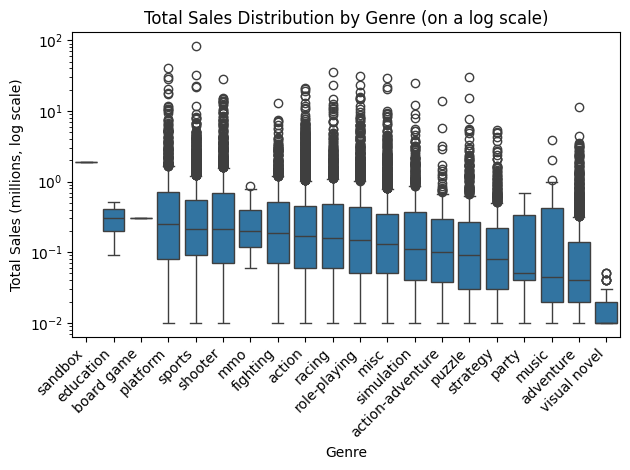

In [38]:
import matplotlib.pyplot as plt 
import seaborn as sns #simple boxplot (gorgeous)
import scipy.stats as stats #stat testing
import scikit_posthocs as sp #for post-hoc test
import numpy as np

#Test 1: Checking for Normality or Variance: 
#group the values in the genre column
genre_sales_groups = [group["total_sales"].values for genre, group in df.groupby("genre")]
#get the test statistic and pvalue for levene test, which checks whether multiple groups have equal variances
levene_statistic,levene_pvalue = stats.levene(*genre_sales_groups)
print(f"Levene's Test-statistic: {levene_statistic}, P-value: {levene_pvalue}")

#Test 2: Kruskal-Wallis: Do the genres differ in total_sales?
#returns the p-value and h statistic and prints it out
kw_statistic,kw_pvalue = stats.kruskal(*genre_sales_groups)
print(f"Kruskal-Wallis H-statistic: {kw_statistic}, P-value: {kw_pvalue}")

#Test 3: Post-hoc test, which is meaningful since p value of the kruskal-wallis test is <0.05
posthoc_dunn_results = sp.posthoc_dunn(
    df,
    val_col="total_sales",
    group_col="genre",
    p_adjust="bonferroni" #just in case to avoid any possible false positives
)

#the dunns test is hard to read so we get only the signifcant values 
#We can do this by using np.triu to get keep only the upper triangle, getting rid of any self comparisons
mask = np.triu(np.ones(posthoc_dunn_results.shape),k=1).astype(bool)
#apply the data_mask to the pvalue matrix, stack() used to convert 2D matrix into a simple 1D list
signficant_values_pairs = posthoc_dunn_results.where(mask).stack() 
# only gives the pairs where pvalue is less than 0.05 and we sort them from least to greatest
signifcant_values_pairs = signficant_values_pairs[signficant_values_pairs < 0.05].sort_values()
print("\n")
print(f"The Significant genre pairs (p < 0.05) for the dunns post-hoc test: \n{signifcant_values_pairs}")

#Gorgeous Plot: Boxplot
plt.figure()
#group the rows by genre and columns for total_sales, get median and sort them from highest to lowest
grouped_data=df.groupby("genre")["total_sales"].median().sort_values(ascending=False).index
#draw a box plot per genre and order=grouped_data ensures genres appear left to right based on ranked above
sns.boxplot(data=df, x="genre", y="total_sales", order=grouped_data)

plt.yscale("log") #needed since total_sales is heavily right-skewed
#rotates genre_names by 45 so they are vertical and easier to read (no overlap)
#ha=right ensures the roated text is directly under the tick 
plt.xticks(rotation=45,ha="right") 

plt.title("Total Sales Distribution by Genre (on a log scale)")
plt.xlabel("Genre")
plt.ylabel("Total Sales (millions, log scale)")
plt.tight_layout()
plt.show()





***CONCLUSION***

***Summary of Dataset:*** Out of the 12 features, we have a total of 19280 rows in our dataset across 19 different video game genres (plus one misc). We found that the sales levels (sales_lvl) are unbalanced because the majority of games fall within the "low" sales range (~5900 records) and only a small fraction of games fall within the "high" sales range (~2100 records). Furthermore, the distribution of the total sales of all video games displays a right-skewed distribution, which prevents us from using standard ANOVA and forced us to use non-parametric testing instead. As expected, the total sales of video games are positively correlated with each regional sales column (na_sales, eu_sales, jp_sales) because total sales is simply the sum of all the regional sales columns.

***Statistical Tests Used:*** Levene's method demonstrated that there were different amounts of variance among the sales of different genres (W = 11.57,p ≈ 6.11 × 10⁻³⁶). This led us to conduct the hypothesis test using the Kruskal-Wallis test to determine that there was a statistically significant relationship between genre and total sales (H =1498.52,p ≈ 9.21 × 10⁻³⁰⁷). We also found that a Dunn's post-hoc test produced 71 of 171 significant genre pair differences. Most notably, the visual novel genre and adventure genre were significantly below the mainstream genres of Sports, Action and Shooter (p < 1 × 10⁻⁹⁰), which is supported by the box-plot depicting the median sales for all the genres.

***Hypothesis Test (Kruskal-Wallis):*** Our Null Hypothesis (H₀) expressed that the sales patterns of video games are similar regardless of their type (No impact on Total Sales). Our alternative hypothesis (Hₐ) regarding sales patterns is that at least one genre has different pricing (Total Sales) from other genres (Yes impact on Total Sales). The application of the Kruskal-Wallis test showed that there is a statistically significant relationship between video game genres and total sales (H = 1498.52, p-value ≈ 9.21 × 10⁻³⁰⁷). As a result, the null hypothesis was rejected because p-value is < 0.05; thus creating a conclusion that genre has a substantial impact on Total Sales.

***Outlier Analysis and Summary:*** Overall, the genre of a game has been identified as a strong indicator of its units sold. Mainstream action-driven genres can sell significantly more than niche genres like visual novel and adventure, although due to a few unique outlier sales of games in both categories, this is difficult to determine using average calculations. The best way to visualize this would be through the boxplot graphic, which shows that the sand box, educational, board, platform and sports games are at the top of the median-sales rank while the adventure and visual novel sit at the bottom. Moreover, all genres have many outlier points associated with their box which represent the small number of exceedingly successful titles that actually raise the average sales of each game's respective genre.

- Conclusion #2:

- Conclusion #3: